In [ ]:
!pip install pmdarima
!pip install --upgrade pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 14.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Emission.csv to Emission.csv


<ipython-input-3-cb8057d778a5>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('Emission.csv', parse_dates=['Year-Month'], index_col='Year-Month')


Valeurs manquantes : CO2          0
month        0
year         0
quarter      0
sin_month    0
cos_month    0
dtype: int64


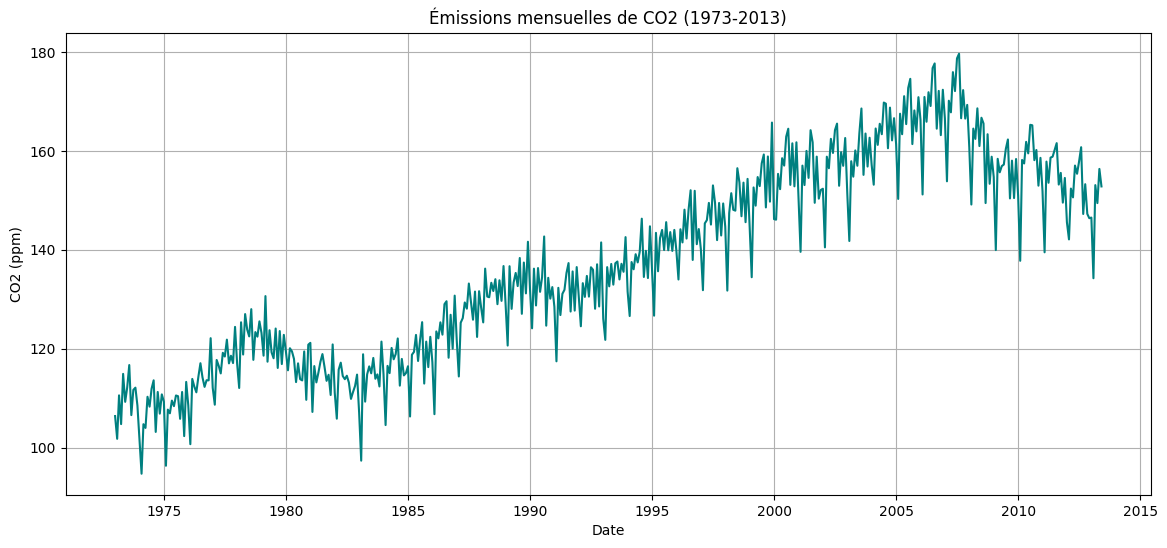

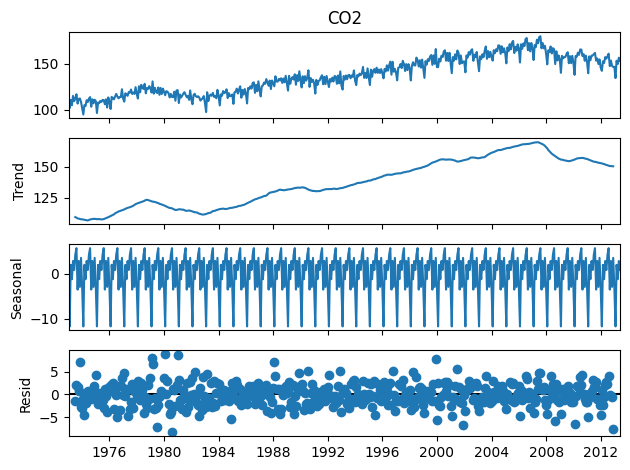

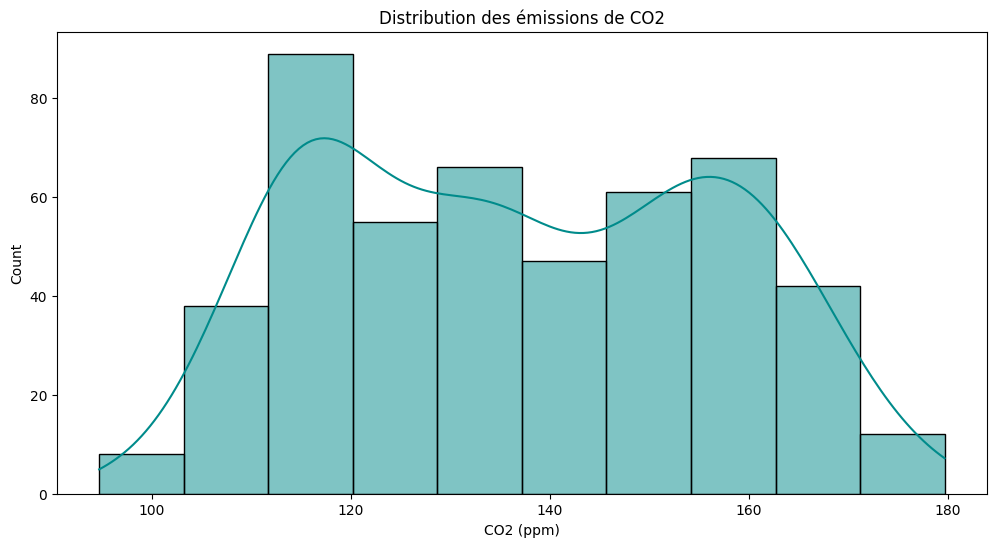

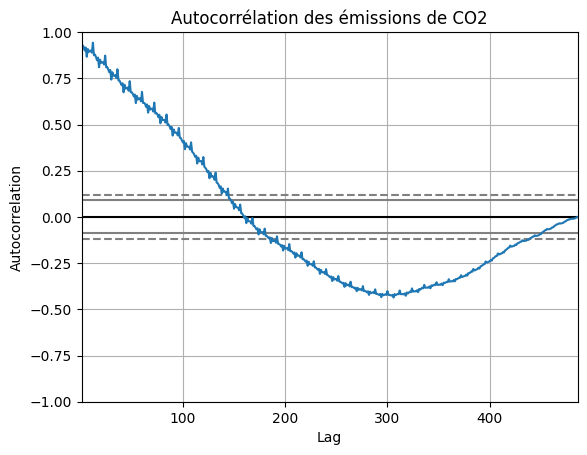


Split des données :
Train : 1973-01 à 2001-04
Val   : 2001-05 à 2007-04
Test  : 2007-05 à 2013-06


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot

import statsmodels.api as sm

# Chargement des données
df = pd.read_csv('Emission.csv', parse_dates=['Year-Month'], index_col='Year-Month')
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)
df.columns = ['CO2']  # Simplification du nom de colonne

# Extraction des caractéristiques temporelles
df['month'] = df.index.month
df['year'] = df.index.year
df['quarter'] = df.index.quarter
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# Vérification des valeurs manquantes
print("Valeurs manquantes :", df.isnull().sum())

# Remplissage des valeurs manquantes (si nécessaire)
df['CO2'] = df['CO2'].interpolate(method='time')

# Exploration visuelle
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['CO2'], color='teal')
plt.title('Émissions mensuelles de CO2 (1973-2013)')
plt.xlabel('Date')
plt.ylabel('CO2 (ppm)')
plt.grid(True)
plt.show()

# Décomposition saisonnière
result = seasonal_decompose(df['CO2'], model='additive', period=12)
result.plot()
plt.tight_layout()
plt.show()

# Distribution des données
plt.figure(figsize=(12, 6))
sns.histplot(df['CO2'], kde=True, color='darkcyan')
plt.title('Distribution des émissions de CO2')
plt.xlabel('CO2 (ppm)')
plt.show()

# Autocorrélation
autocorrelation_plot(df['CO2'])
plt.title('Autocorrélation des émissions de CO2')
plt.show()

# Division des données (70% train, 15% validation, 15% test)
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))

train = df.iloc[:train_size]
val = df.iloc[train_size:train_size + val_size]
test = df.iloc[train_size + val_size:]

# Normalisation (pour modèles sensibles à l'échelle)
scaler = MinMaxScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train[['CO2']]), index=train.index, columns=['CO2'])
val_scaled = pd.DataFrame(scaler.transform(val[['CO2']]), index=val.index, columns=['CO2'])
test_scaled = pd.DataFrame(scaler.transform(test[['CO2']]), index=test.index, columns=['CO2'])

# Affichage des splits
print("\nSplit des données :")
print(f"Train : {train.index[0].strftime('%Y-%m')} à {train.index[-1].strftime('%Y-%m')}")
print(f"Val   : {val.index[0].strftime('%Y-%m')} à {val.index[-1].strftime('%Y-%m')}")
print(f"Test  : {test.index[0].strftime('%Y-%m')} à {test.index[-1].strftime('%Y-%m')}")

# Sauvegarde des données prétraitées (optionnel)
train_scaled.to_csv('train_scaled.csv')
val_scaled.to_csv('val_scaled.csv')
test_scaled.to_csv('test_scaled.csv')


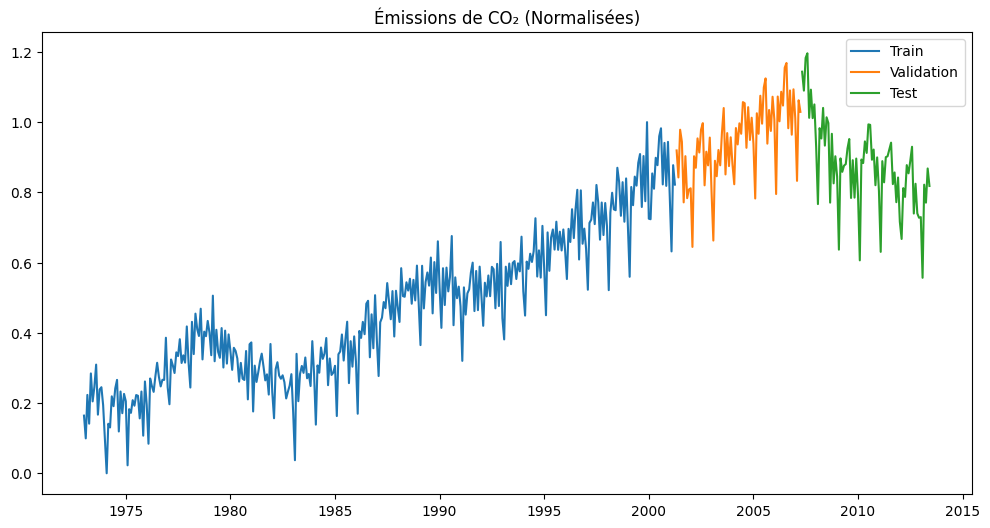

p-value (ADF): 0.877036332278571
p-value après différenciation: 0.008280590896490452


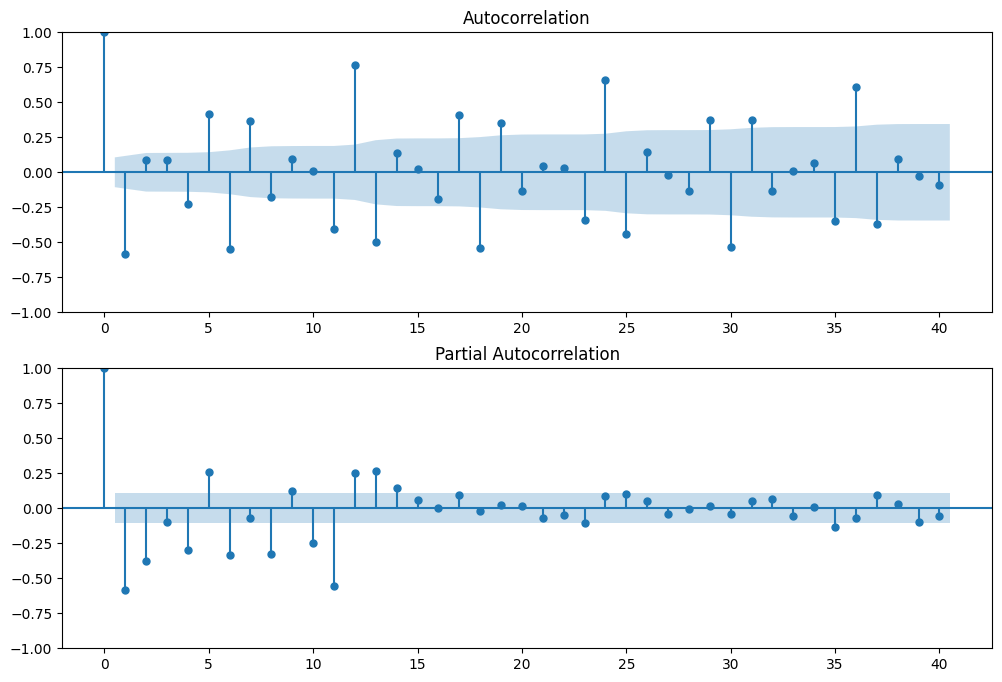

 Début de la recherche des paramètres optimaux avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-578.959, Time=0.11 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-717.084, Time=0.11 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-790.998, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-580.838, Time=0.11 sec


...

 ARIMA(5,1,5)(0,0,0)[0] intercept   : AIC=inf, Time=4.47 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,1,4)(0,0,0)[0]             : AIC=inf, Time=1.12 sec

Best model:  ARIMA(4,1,4)(0,0,0)[0] intercept
Total fit time: 38.103 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  340
Model:               SARIMAX(4, 1, 4)   Log Likelihood                 467.749
Date:                Wed, 07 May 2025   AIC                           -915.499
Time:                        20:56:10   BIC                           -877.239
Sample:                    01-01-1973   HQIC                          -900.252
                         - 04-01-2001                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0019      0.001      2.238      0.025       0.000     

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 Modèle entraîné en 1.11 secondes

 Prédiction sur l'ensemble d'entraînement...


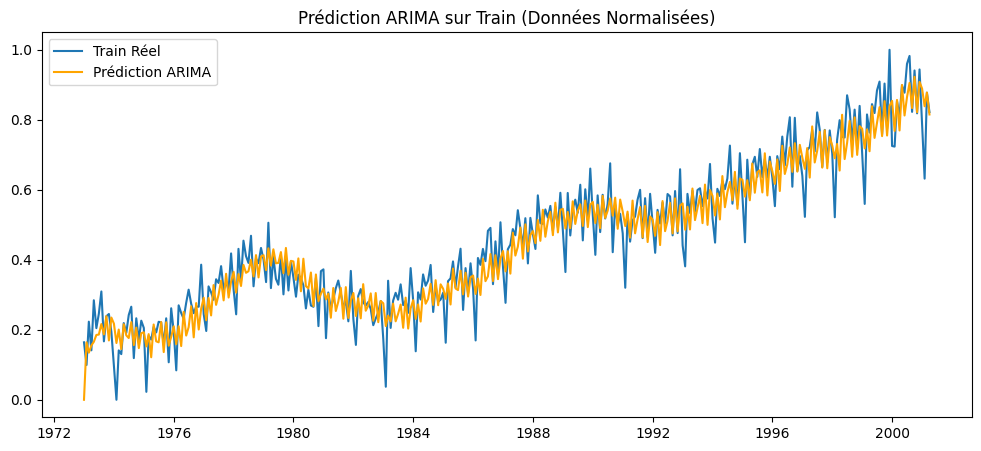

Train MSE: 0.0038, MAE: 0.0478, RMSE: 0.0615, R²: 0.9128
 Temps d'inférence (train): 0.0004 secondes

 Prédiction sur l'ensemble de validation...


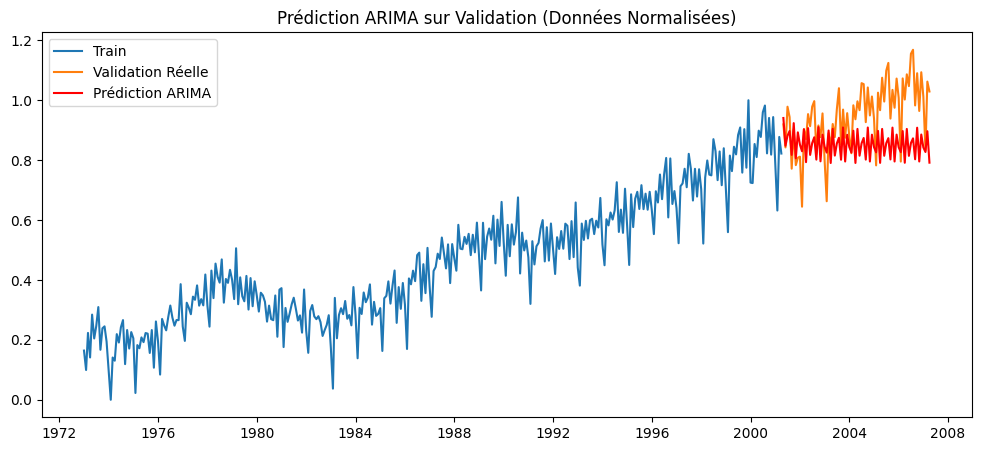

Validation MSE: 0.0191, MAE: 0.1160, RMSE: 0.1384, R²: -0.6757
 Temps d'inférence (validation): 0.0135 secondes

 Ré-entraînement sur Train + Val...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



 Prédiction sur l'ensemble de test...


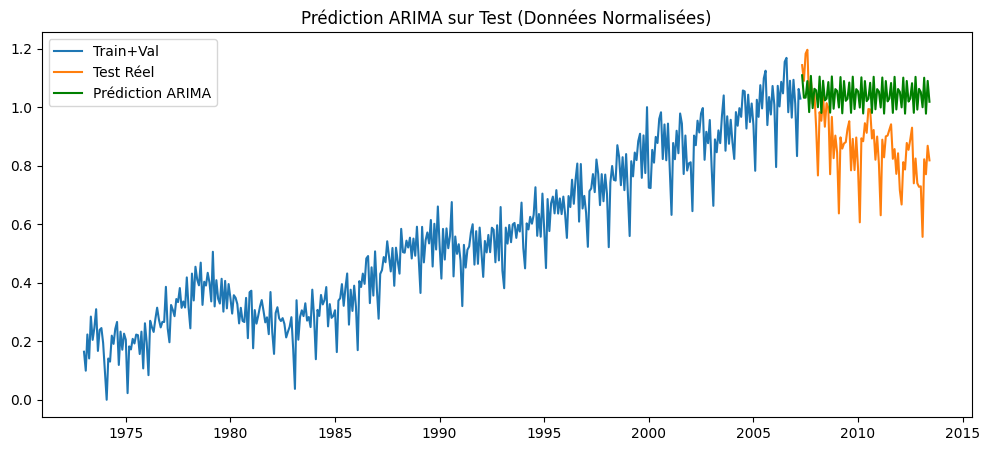

Test MSE: 0.0400, MAE: 0.1761, RMSE: 0.2001, R²: -1.6255
 Temps d'inférence (test): 0.0181 secondes


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
from statsmodels.tsa.stattools import adfuller
import time


#Visualisons la série temporelle pour identifier les tendances, saisonnalités et anomalies

plt.figure(figsize=(12, 6))
plt.plot(train_scaled, label='Train')
plt.plot(val_scaled, label='Validation')
plt.plot(test_scaled, label='Test')
plt.title('Émissions de CO₂ (Normalisées)')
plt.legend()
plt.show()



#Vérification de la Stationnarité
# Test ADF sur l'ensemble d'entraînement
result = adfuller(train_scaled['CO2'])
print(f"p-value (ADF): {result[1]}")  # p-value > 0.05 → non stationnaire

# Différenciation pour rendre stationnaire
train_diff = train_scaled.diff().dropna()
result_diff = adfuller(train_diff['CO2'])
print(f"p-value après différenciation: {result_diff[1]}")  # p-value < 0.05 → stationnaire


# -------------------------------------------------------------------
#Identification des Paramètres (p, d, q) avec ACF/PACF
# -------------------------------------------------------------------
# ACF et PACF après différenciation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
sm.graphics.tsa.plot_acf(train_diff, lags=40, ax=ax1)
sm.graphics.tsa.plot_pacf(train_diff, lags=40, ax=ax2)
plt.show()

# --- Étape 1 : Recherche automatique des meilleurs paramètres ARIMA ---
print(" Début de la recherche des paramètres optimaux avec auto_arima...")
stepwise_model = auto_arima(
    train_scaled['CO2'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,           # auto
    seasonal=False,   # Pas de saisonnalité
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(stepwise_model.summary())
order = stepwise_model.order

# --- Étape 2 : Entraînement du modèle ARIMA optimal avec mesure du temps ---
print("\n Entraînement du modèle ARIMA sur l'ensemble d'entraînement...")
start_time = time.time()
model = ARIMA(train_scaled['CO2'], order=order)
model_fit = model.fit()
training_time = time.time() - start_time
print(f" Modèle entraîné en {training_time:.2f} secondes")

# --- Étape 3 : Prédiction sur l'ensemble d'entraînement avec temps d'inférence ---
print("\n Prédiction sur l'ensemble d'entraînement...")
start_inference_train = time.time()
forecast_train = model_fit.fittedvalues
inference_train_time_arima = time.time() - start_inference_train

# Graphique
plt.figure(figsize=(12, 5))
plt.plot(train_scaled.index, train_scaled['CO2'], label='Train Réel')
plt.plot(train_scaled.index, forecast_train, label='Prédiction ARIMA', color='orange')
plt.legend()
plt.title('Prédiction ARIMA sur Train (Données Normalisées)')
plt.show()

# Métriques
mse_train_arima = mean_squared_error(train_scaled['CO2'], forecast_train)
mae_train_arima = mean_absolute_error(train_scaled['CO2'], forecast_train)
rmse_train_arima = sqrt(mse_train_arima)
r2_train_arima = r2_score(train_scaled['CO2'], forecast_train)
print(f"Train MSE: {mse_train_arima:.4f}, MAE: {mae_train_arima:.4f}, RMSE: {rmse_train_arima:.4f}, R²: {r2_train_arima:.4f}")
print(f" Temps d'inférence (train): {inference_train_time_arima:.4f} secondes")

# --- Étape 4 : Prédiction sur validation avec temps d'inférence ---
print("\n Prédiction sur l'ensemble de validation...")
start_inference_val = time.time()
forecast_val = model_fit.forecast(steps=len(val_scaled))
inference_val_time_arima = time.time() - start_inference_val


# Graphique
plt.figure(figsize=(12, 5))
plt.plot(train_scaled.index, train_scaled['CO2'], label='Train')
plt.plot(val_scaled.index, val_scaled['CO2'], label='Validation Réelle')
plt.plot(val_scaled.index, forecast_val, label='Prédiction ARIMA', color='red')
plt.legend()
plt.title('Prédiction ARIMA sur Validation (Données Normalisées)')
plt.show()

# Métriques
mse_val_arima = mean_squared_error(val_scaled['CO2'], forecast_val)
mae_val_arima = mean_absolute_error(val_scaled['CO2'], forecast_val)
rmse_val_arima = sqrt(mse_val_arima)
r2_val_arima = r2_score(val_scaled['CO2'], forecast_val)
print(f"Validation MSE: {mse_val_arima:.4f}, MAE: {mae_val_arima:.4f}, RMSE: {rmse_val_arima:.4f}, R²: {r2_val_arima:.4f}")
print(f" Temps d'inférence (validation): {inference_val_time_arima:.4f} secondes")

# --- Étape 5 : Ré-entrainement sur train+val + prédiction sur test avec inférence ---
print("\n Ré-entraînement sur Train + Val...")
full_train = pd.concat([train_scaled, val_scaled])
model_final = ARIMA(full_train['CO2'], order=order)
model_final_fit = model_final.fit()

print("\n Prédiction sur l'ensemble de test...")
start_inference_test = time.time()
forecast_test = model_final_fit.forecast(steps=len(test_scaled))
inference_test_time_arima = time.time() - start_inference_test

# Graphique
plt.figure(figsize=(12, 5))
plt.plot(full_train.index, full_train['CO2'], label='Train+Val')
plt.plot(test_scaled.index, test_scaled['CO2'], label='Test Réel')
plt.plot(test_scaled.index, forecast_test, label='Prédiction ARIMA', color='green')
plt.legend()
plt.title('Prédiction ARIMA sur Test (Données Normalisées)')
plt.show()

# Métriques
mse_test_arima = mean_squared_error(test_scaled['CO2'], forecast_test)
mae_test_arima = mean_absolute_error(test_scaled['CO2'], forecast_test)
rmse_test_arima = sqrt(mse_test_arima)
r2_test_arima = r2_score(test_scaled['CO2'], forecast_test)
print(f"Test MSE: {mse_test_arima:.4f}, MAE: {mae_test_arima:.4f}, RMSE: {rmse_test_arima:.4f}, R²: {r2_test_arima:.4f}")
print(f" Temps d'inférence (test): {inference_test_time_arima:.4f} secondes")



Meilleur modèle SARIMA trouvé : order=(1, 0, 1), seasonal_order=(1, 1, 0, 12)
Nombre de paramètres: 4
Temps d'entraînement: 0.39 secondes
Temps d'inférence: 0.03 secondes
                                      SARIMAX Results                                      
Dep. Variable:                                 CO2   No. Observations:                  340
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 12)   Log Likelihood                 523.781
Date:                             Wed, 07 May 2025   AIC                          -1039.562
Time:                                     20:57:46   BIC                          -1024.552
Sample:                                 01-01-1973   HQIC                         -1033.565
                                      - 04-01-2001                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------

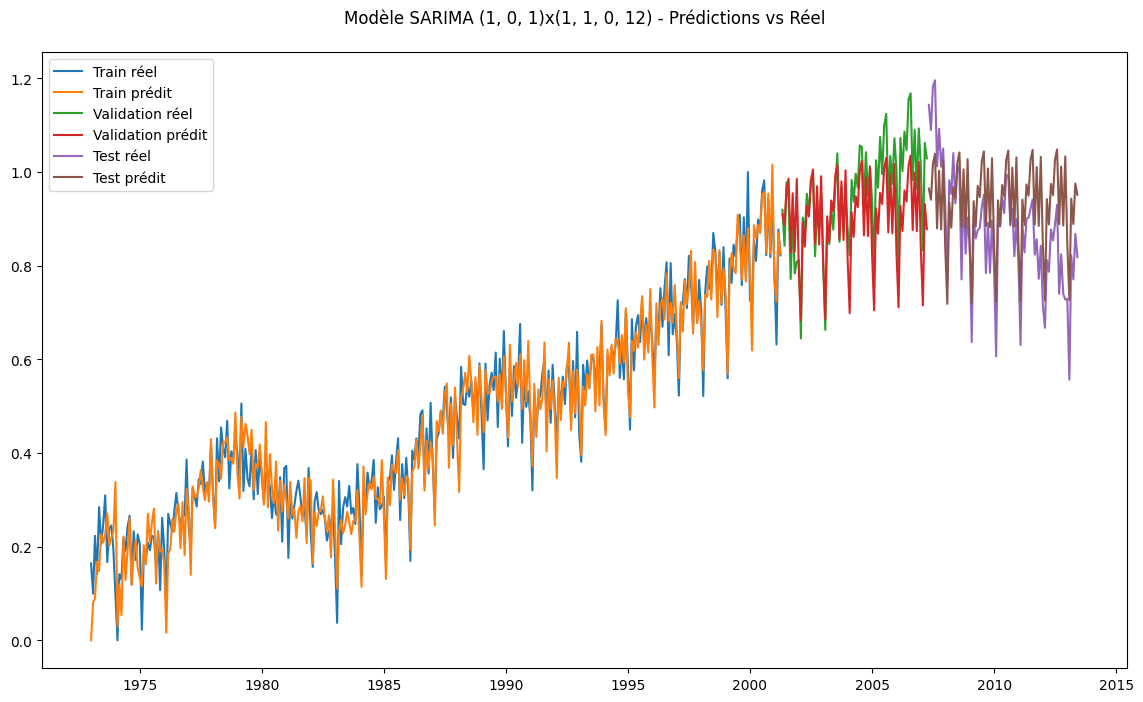

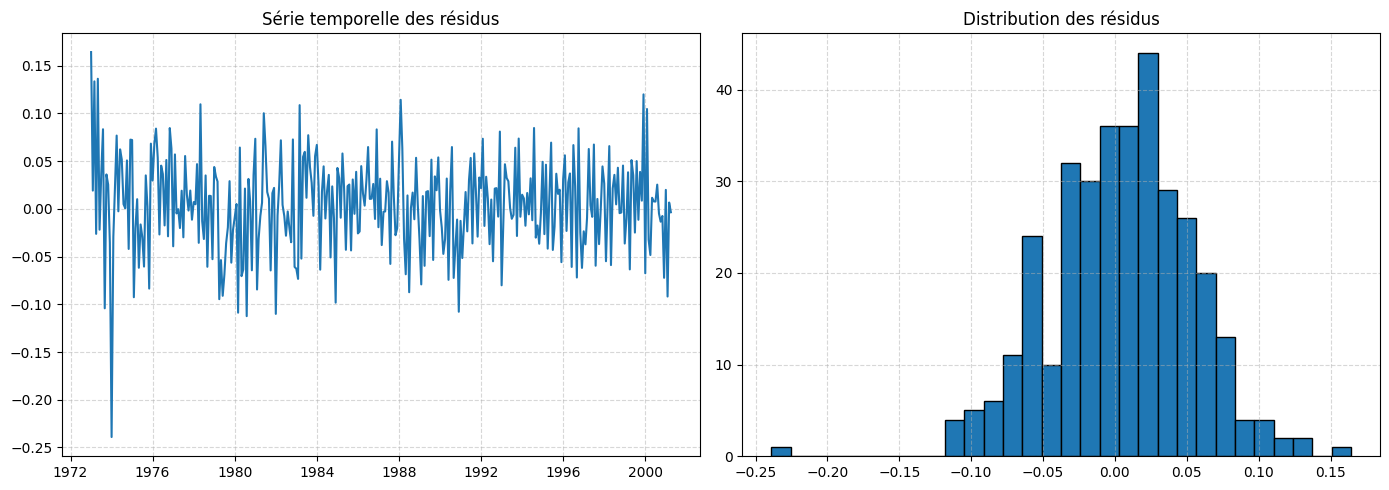

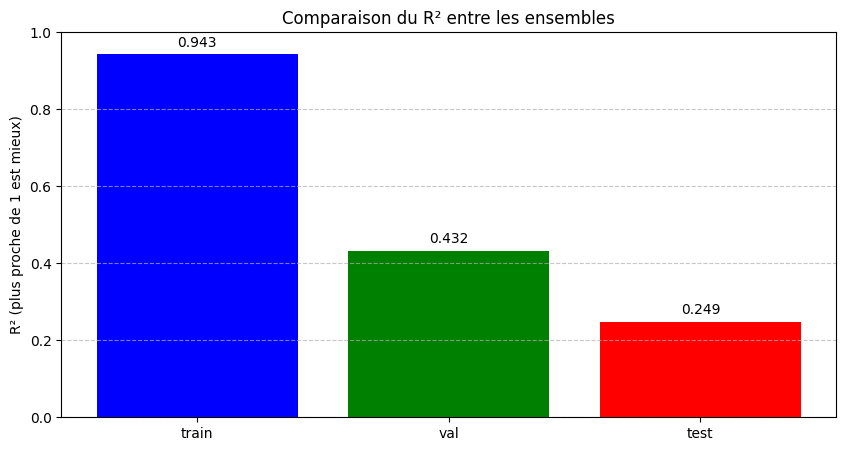

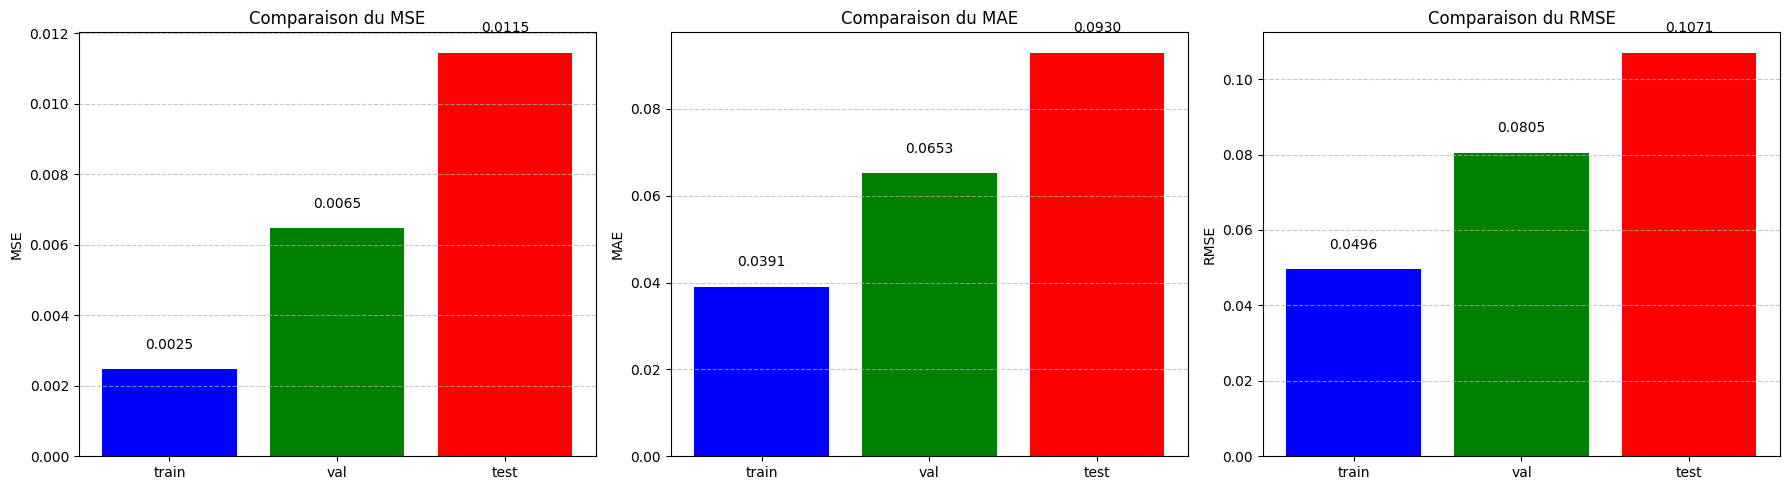

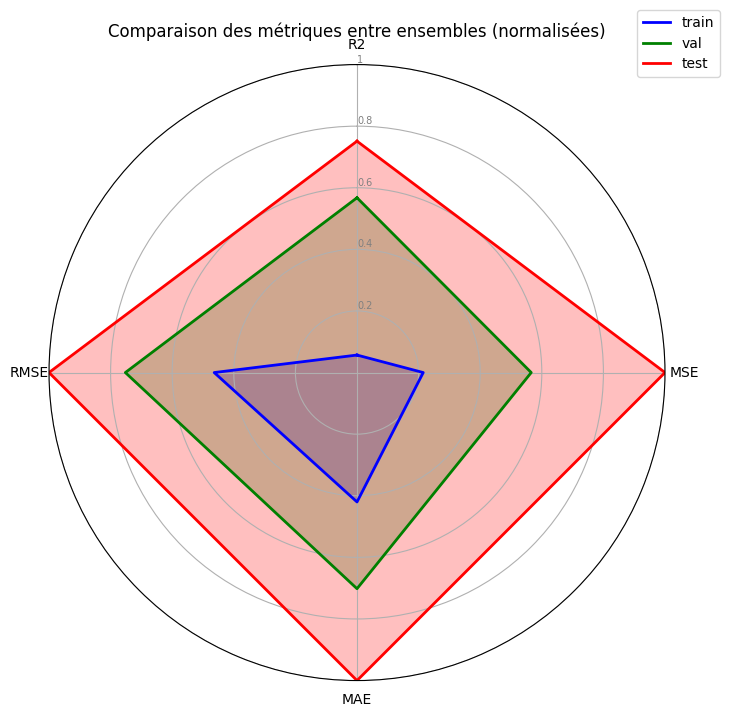

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import time
import warnings
warnings.filterwarnings('ignore')

# Chargement des données
train = pd.read_csv('train_scaled.csv', parse_dates=['Year-Month'], index_col='Year-Month')
val = pd.read_csv('val_scaled.csv', parse_dates=['Year-Month'], index_col='Year-Month')
test = pd.read_csv('test_scaled.csv', parse_dates=['Year-Month'], index_col='Year-Month')

y_train = train['CO2']
y_val = val['CO2']
y_test = test['CO2']

best_order = None
best_seasonal_order = None
best_r2_val = -np.inf
best_model = None

# Recherche SARIMA : p,d,q x P,D,Q,s
for p in range(3):
    for d in range(2):
        for q in range(3):
            for P in range(2):
                for D in range(2):
                    for Q in range(2):
                        for s in [12]:  # saisonnalité annuelle (12 mois)
                            try:
                                start_time = time.time()
                                model = SARIMAX(y_train,
                                                order=(p,d,q),
                                                seasonal_order=(P,D,Q,s),
                                                enforce_stationarity=False,
                                                enforce_invertibility=False)
                                model_fit = model.fit(disp=False)
                                training_time = time.time() - start_time

                                # Prédiction et calcul du temps d'inférence
                                start_inf_time = time.time()
                                pred_train = model_fit.predict(start=y_train.index[0], end=y_train.index[-1])
                                pred_val = model_fit.predict(start=y_val.index[0], end=y_val.index[-1])
                                pred_test = model_fit.predict(start=y_test.index[0], end=y_test.index[-1])
                                inference_time = time.time() - start_inf_time

                                # Calcul des métriques
                                def calculate_metrics(y_true, y_pred):
                                    return {
                                        'R2': r2_score(y_true, y_pred),
                                        'MSE': mean_squared_error(y_true, y_pred),
                                        'MAE': mean_absolute_error(y_true, y_pred),
                                        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
                                    }

                                metrics_train = calculate_metrics(y_train, pred_train)
                                metrics_val = calculate_metrics(y_val, pred_val)
                                metrics_test = calculate_metrics(y_test, pred_test)

                                # Nombre de paramètres
                                n_params = len(model_fit.params)

                                # Critère de sélection
                                if (metrics_train['R2'] > 0 and metrics_val['R2'] > 0 and
                                    metrics_test['R2'] > 0 and metrics_val['R2'] > best_r2_val):
                                    best_order = (p,d,q)
                                    best_seasonal_order = (P,D,Q,s)
                                    best_r2_val = metrics_val['R2']
                                    best_model = model_fit
                                    best_preds = (pred_train, pred_val, pred_test)
                                    best_metrics = {
                                        'train': metrics_train,
                                        'val': metrics_val,
                                        'test': metrics_test
                                    }
                                    best_times = {
                                        'training_time': training_time,
                                        'inference_time': inference_time
                                    }
                                    best_n_params = n_params
                            except Exception as e:
                                continue

if best_model is None:
    print("Aucun modèle SARIMA testé ne satisfait R² > 0 sur train, val et test.")
else:
    print(f"Meilleur modèle SARIMA trouvé : order={best_order}, seasonal_order={best_seasonal_order}")
    print(f"Nombre de paramètres: {best_n_params}")
    print(f"Temps d'entraînement: {best_times['training_time']:.2f} secondes")
    print(f"Temps d'inférence: {best_times['inference_time']:.2f} secondes")

    # Affichage des résultats détaillés
    print(best_model.summary())

    # Affichage des métriques pour chaque ensemble
    for dataset in ['train', 'val', 'test']:
        print(f"\nMétriques pour l'ensemble {dataset}:")
        print(f"R²: {best_metrics[dataset]['R2']:.4f}")
        print(f"MSE: {best_metrics[dataset]['MSE']:.4f}")
        print(f"MAE: {best_metrics[dataset]['MAE']:.4f}")
        print(f"RMSE: {best_metrics[dataset]['RMSE']:.4f}")

    # Visualisation
    plt.figure(figsize=(14,8))
    plt.plot(train.index, y_train, label='Train réel')
    plt.plot(train.index, best_preds[0], label='Train prédit')
    plt.plot(val.index, y_val, label='Validation réel')
    plt.plot(val.index, best_preds[1], label='Validation prédit')
    plt.plot(test.index, y_test, label='Test réel')
    plt.plot(test.index, best_preds[2], label='Test prédit')
    plt.legend()
    plt.title(f'Modèle SARIMA {best_order}x{best_seasonal_order} - Prédictions vs Réel\n')
    plt.show()

     # Analyse des résidus
    residuals = best_model.resid
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(residuals)
    axes[0].set_title('Série temporelle des résidus')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    axes[1].hist(residuals, bins=30, edgecolor='black')
    axes[1].set_title('Distribution des résidus')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

  # Nouveaux graphiques de comparaison des métriques
    metrics_names = ['R2', 'MSE', 'MAE', 'RMSE']
    datasets = ['train', 'val', 'test']

    # Création des données pour les graphiques
    metrics_data = {
        'R2': [best_metrics[dataset]['R2'] for dataset in datasets],
        'MSE': [best_metrics[dataset]['MSE'] for dataset in datasets],
        'MAE': [best_metrics[dataset]['MAE'] for dataset in datasets],
        'RMSE': [best_metrics[dataset]['RMSE'] for dataset in datasets]
    }

    # Graphique en barres pour R2
    plt.figure(figsize=(10, 5))
    plt.bar(datasets, metrics_data['R2'], color=['blue', 'green', 'red'])
    plt.title('Comparaison du R² entre les ensembles')
    plt.ylabel('R² (plus proche de 1 est mieux)')
    plt.ylim(0, 1)
    for i, v in enumerate(metrics_data['R2']):
        plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Graphique en barres pour MSE, MAE, RMSE
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, metric in enumerate(['MSE', 'MAE', 'RMSE']):
        axes[i].bar(datasets, metrics_data[metric], color=['blue', 'green', 'red'])
        axes[i].set_title(f'Comparaison du {metric}')
        axes[i].set_ylabel(metric)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

        # Ajout des valeurs sur les barres
        for j, v in enumerate(metrics_data[metric]):
            axes[i].text(j, v + max(metrics_data[metric])*0.05, f"{v:.4f}", ha='center')

    plt.tight_layout()
    plt.show()

    # Graphique radar pour comparer toutes les métriques
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    # Préparation des angles
    angles = np.linspace(0, 2*np.pi, len(metrics_names), endpoint=False).tolist()
    angles += angles[:1]  # Fermer le cercle

    # Normalisation des métriques (sauf R2)
    max_values = {
        'MSE': max(metrics_data['MSE']),
        'MAE': max(metrics_data['MAE']),
        'RMSE': max(metrics_data['RMSE'])
    }

    # Fonction de normalisation inverse pour R2
    def normalize_metric(metric, value):
        if metric == 'R2':
            return 1 - value  # On veut que 1 soit le meilleur
        return value / max_values[metric]

    # Tracé pour chaque dataset
    colors = ['b', 'g', 'r']
    for idx, dataset in enumerate(datasets):
        values = []
        for metric in metrics_names:
            values.append(normalize_metric(metric, best_metrics[dataset][metric]))
        values += values[:1]  # Fermer le cercle

        ax.plot(angles, values, color=colors[idx], linewidth=2, label=dataset)
        ax.fill(angles, values, color=colors[idx], alpha=0.25)

    # Paramétrage du graphique
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), metrics_names)

    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1], ["0.2", "0.4", "0.6", "0.8", "1"], color="grey", size=7)
    plt.ylim(0, 1)

    plt.title('Comparaison des métriques entre ensembles (normalisées)', pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    plt.show()

    # Métriques sur test du meilleur modèle SARIMA
    mse_test_sarima = best_metrics['test']['MSE']
    mae_test_sarima = best_metrics['test']['MAE']
    rmse_test_sarima = best_metrics['test']['RMSE']
    r2_test_sarima = best_metrics['test']['R2']
    training_time_sarima = best_times['training_time']
    inference_time_sarima = best_times['inference_time']
    n_params_sarima = best_n_params

In [ ]:
# Prédiction de 13 eme  mois du modele SARIMA
future_steps = 12
future_index = pd.date_range(start=y_test.index[-1] + pd.DateOffset(months=1), periods=future_steps, freq='MS')

# Générer les prédictions futures
future_forecast = best_model.predict(start=future_index[0], end=future_index[-1])

# Afficher les prédictions
future_df = pd.DataFrame({'CO2_Prédit': future_forecast}, index=future_index)
print("\nPrévisions de niveau de CO₂ pour le 13 eme mois :")
print(future_df)

#  Visualisation de la progression future de niveau de CO₂
plt.figure(figsize=(14,6))
plt.plot(y_train.index, y_train, label='Train réel')
plt.plot(y_val.index, y_val, label='Validation réel')
plt.plot(y_test.index, y_test, label='Test réel')
plt.plot(future_index, future_forecast, label='Prévision future mois', linestyle='--', color='black')
plt.title("Évolutionde niveau de CO₂ pour le 13 eme mois")
plt.xlabel("Date")
plt.ylabel("CO₂ (normalisé)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 1.8385 - mae: 1.0708 - val_loss: 0.7589 - val_mae: 0.7043 - learning_rate: 0.0010
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 1.1247 - mae: 0.7928 - val_loss: 0.7496 - val_mae: 0.7025 - learning_rate: 0.0010
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.0150 - mae: 0.7714 - val_loss: 0.7571 - val_mae: 0.7057 - learning_rate: 0.0010
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.1202 - mae: 0.8099 - val_loss: 0.7506 - val_mae: 0.7024 - learning_rate: 0.0010
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.9355 - mae: 0.7496 - val_loss: 0.7497 - val_mae: 0.7030 - learning_rate: 0.0010
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.7765 - mae: 0.6744 - val_loss: 0.7419 - val_mae: 0.6997 - learning_rate: 0.0010
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.7849 - mae: 0.6611 - val_loss: 0.7458 - val_mae: 0.7005 - learning_rate: 0.0010
Epoch

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 24, 64)              │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 24, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 90,341 (352.90 KB)

 Trainable params: 30,049 (117.38 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 60,100 (234.77 KB)


Nombre total de paramètres: 30,241

Temps d'entraînement total: 61.58 secondes

=== Ensemble TRAIN ===
MSE: 1.2532
MAE: 0.9001
R²: 0.9963
Temps d’inférence: 0.8318 secondes

=== Ensemble VAL ===
MSE: 1.7132
MAE: 1.1798
R²: 0.9632
Temps d’inférence: 0.1011 secondes

=== Ensemble TEST ===
MSE: 12.4889
MAE: 2.6329
R²: 0.7300
Temps d’inférence: 0.0948 secondes



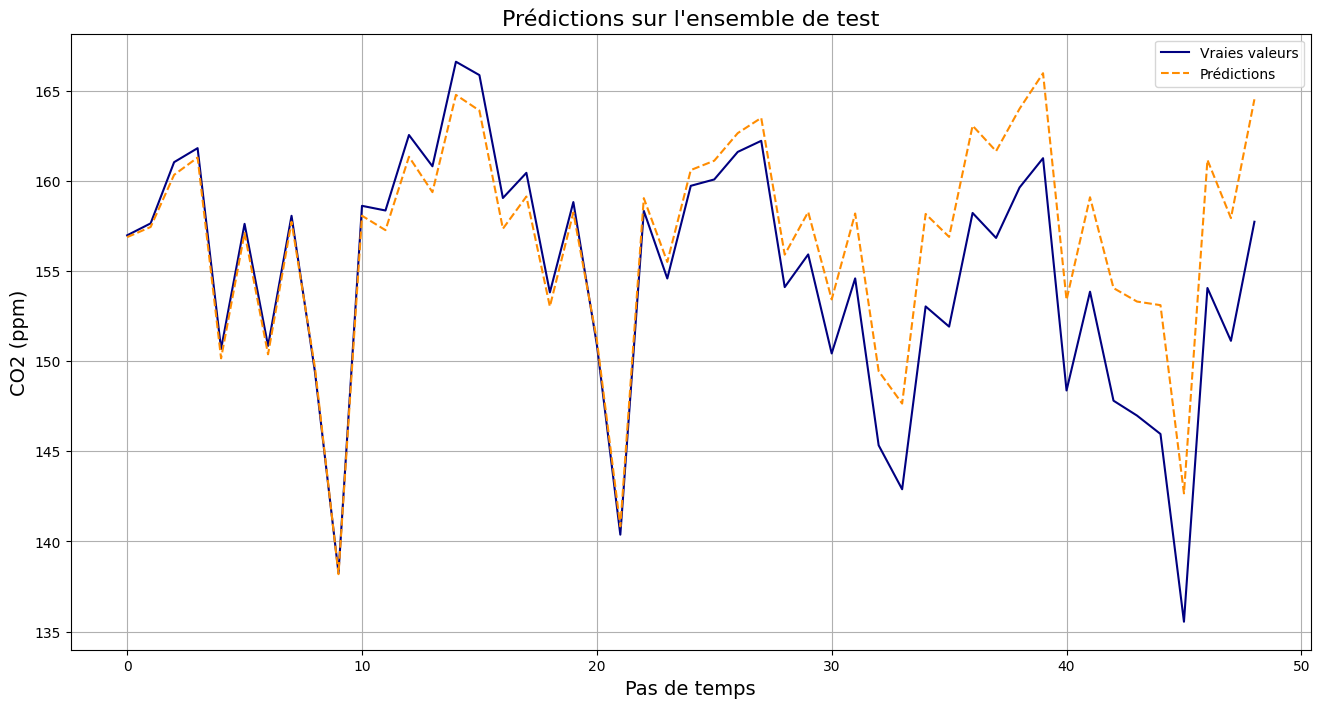

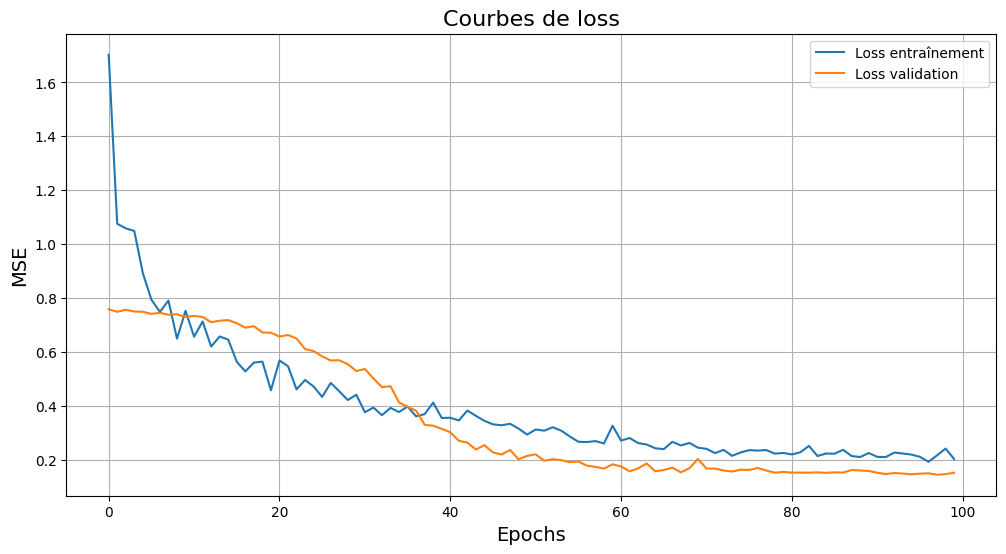

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Sequential #new a ajouter dans le rapport
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization # new ajouter dans le rapport
from tensorflow.keras.regularizers import L1L2 #new a ajouter dans le rapport
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # new a ajouter dans le rapport
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time #new a ajouter dans le rapport
import random
import tensorflow as tf
import os


# 1. Chargement et parsing
df = pd.read_csv('Emission.csv', parse_dates=['Year-Month'], index_col='Year-Month', dayfirst=False)
df.index = pd.to_datetime(df.index, format='%Y-%b')
df.columns = ['CO2']

# 2. Feature Engineering
df['month'] = df.index.month
df['sin_month'] = np.sin(2 * np.pi * df['month']/12)
df['cos_month'] = np.cos(2 * np.pi * df['month']/12)
df.drop('month', axis=1, inplace=True)
df['trend'] = np.arange(len(df))

# 3. Différenciation
df['CO2_diff'] = df['CO2'].diff().fillna(0)

# 4. Split temporel
train = df.iloc[:int(0.7*len(df))]
val = df.iloc[int(0.7*len(df)):int(0.85*len(df))]
test = df.iloc[int(0.85*len(df)):]

# 5. Normalisation robuste
features = ['CO2_diff', 'sin_month', 'cos_month']
scaler = RobustScaler() #a ajouter dans le rapport
train_scaled = pd.DataFrame(scaler.fit_transform(train[features]), index=train.index, columns=features)
val_scaled = pd.DataFrame(scaler.transform(val[features]), index=val.index, columns=features)
test_scaled = pd.DataFrame(scaler.transform(test[features]), index=test.index, columns=features)

# Fonction de création des séquences
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data)-n_steps):
        X.append(data.iloc[i:i+n_steps].values)
        y.append(data.iloc[i+n_steps, 0])
    return np.array(X), np.array(y)

n_steps = 24 # Fenêtre étendue trainingsur 24 mois sur 200 iterations
#on utilise pas la window_size
n_features = len(features)

X_train, y_train = create_sequences(train_scaled, n_steps)
X_val, y_val = create_sequences(val_scaled, n_steps)
X_test, y_test = create_sequences(test_scaled, n_steps)

# Ajout d'un bruit léger sur X_train pour éviter overfitting
noise = np.random.normal(0, 0.01, X_train.shape)
X_train_noisy = X_train + noise

# 6. Modèle modifié
model = Sequential([
    LSTM(64, activation='tanh',
         kernel_regularizer=L1L2(l1=1e-4, l2=1e-3),
         return_sequences=True,
         input_shape=(n_steps, n_features)),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32, activation='tanh',
         kernel_regularizer=L1L2(l2=1e-3)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1)
])

# 7. Configuration de l'entraînement
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

start_time = time.time()
history = model.fit(
    X_train_noisy, y_train,
    epochs=100,
    batch_size=24,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
training_time = time.time() - start_time

# Affichage du résumé
print("\n" + "="*60)
model.summary()
print(f"\nNombre total de paramètres: {model.count_params():,}")
print("="*60 + "\n")

# --- ÉVALUATION ---
def inverse_transform(y_diff, last_values):
    return last_values + y_diff.cumsum()

def evaluate_model(X, y, reference):
    start_time = time.time()
    y_pred = model.predict(X, verbose=0).flatten()
    pred_time = time.time() - start_time

    last_train_values = reference['CO2'].iloc[-len(y)-1:-1].values
    y_true = inverse_transform(y, last_train_values)
    y_pred = inverse_transform(y_pred, last_train_values)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
        'pred_time': pred_time,
        'true': y_true,
        'pred': y_pred
    }

# Résultats
results = {
    'train': evaluate_model(X_train, y_train, train),
    'val': evaluate_model(X_val, y_val, val),
    'test': evaluate_model(X_test, y_test, test)
}

# --- Métriques sur test du meilleur modèle LSTM ---
mse_test_lstm = results['test']['mse']
mae_test_lstm = results['test']['mae']
rmse_test_lstm = results['test']['rmse']
r2_test_lstm = results['test']['r2']
training_time_lstm = training_time
inference_time_lstm = results['test']['pred_time']
n_params_lstm = model.count_params()


#prediction de 25 eme mois
print(f"Temps d'entraînement total: {training_time:.2f} secondes\n")
for dataset in ['train', 'val', 'test']:
    res = results[dataset]
    print(f"=== Ensemble {dataset.upper()} ===")
    print(f"MSE: {res['mse']:.4f}")
    print(f"MAE: {res['mae']:.4f}")
    print(f"R²: {res['r2']:.4f}")
    print(f"Temps d’inférence: {res['pred_time']:.4f} secondes\n")

# --- VISUALISATION ---
plt.figure(figsize=(16, 8))
plt.plot(results['test']['true'], label='Vraies valeurs', color='navy')
plt.plot(results['test']['pred'], label='Prédictions', color='darkorange', linestyle='--')
plt.title('Prédictions sur l\'ensemble de test', fontsize=16)
plt.xlabel('Pas de temps', fontsize=14)
plt.ylabel('CO2 (ppm)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# --- Courbe d'apprentissage ---
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Loss entraînement')
plt.plot(history.history['val_loss'], label='Loss validation')
plt.title('Courbes de loss', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('MSE', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


Valeur prédite pour le prochain mois (25ème mois): 153.17 ppm


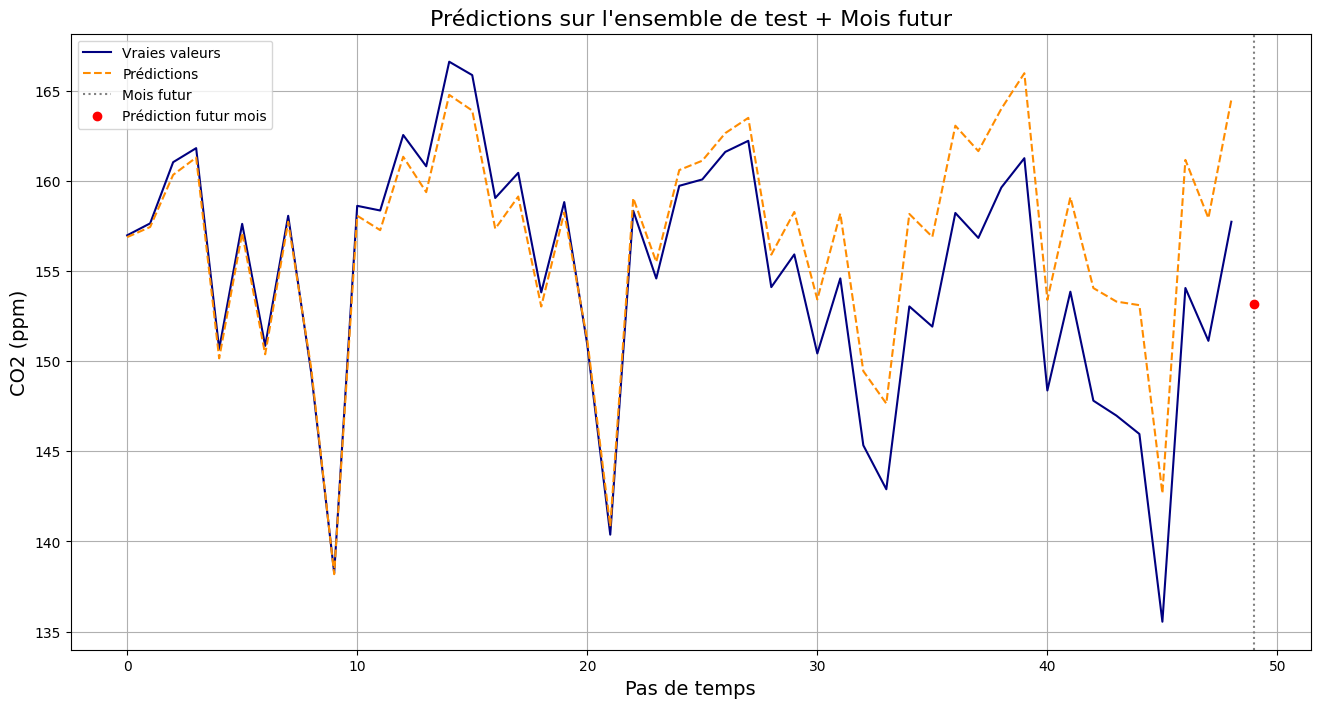

In [ ]:
# PRÉDICTION DU MOIS SUIVANT (25ème mois)
last_sequence = test_scaled.iloc[-n_steps:].values  # dernière séquence connue
last_sequence = last_sequence.reshape(1, n_steps, n_features)
future_diff = model.predict(last_sequence, verbose=0)[0][0]  # prédiction de la diff

# Valeur réelle du dernier mois
last_real_value = df['CO2'].iloc[-1]

# Valeur prédite pour le mois suivant
future_value = last_real_value + future_diff
print(f"Valeur prédite pour le prochain mois (25ème mois): {future_value:.2f} ppm")
# Ajout de la prédiction future au graphe test
true_values = results['test']['true']
pred_values = results['test']['pred']

plt.figure(figsize=(16, 8))
plt.plot(true_values, label='Vraies valeurs', color='navy')
plt.plot(pred_values, label='Prédictions', color='darkorange', linestyle='--')

# Ajout du point futur prédit
plt.axvline(x=len(true_values), color='gray', linestyle=':', label='Mois futur')
plt.scatter(len(true_values), future_value, color='red', label='Prédiction futur mois', zorder=5)

plt.title("Prédictions sur l'ensemble de test + Mois futur", fontsize=16)
plt.xlabel("Pas de temps", fontsize=14)
plt.ylabel("CO2 (ppm)", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.6030 - mae: 0.6184 - val_loss: 0.6647 - val_mae: 0.7027 - learning_rate: 0.0010
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4923 - mae: 0.5876 - val_loss: 0.6622 - val_mae: 0.7040 - learning_rate: 0.0010
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5226 - mae: 0.5993 - val_loss: 0.6622 - val_mae: 0.7040 - learning_rate: 0.0010
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5118 - mae: 0.5861 - val_loss: 0.6635 - val_mae: 0.7031 - learning_rate: 0.0010
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4936 - mae: 0.5748 - val_loss: 0.6649 - val_mae: 0.7027 - learning_rate: 0.0010
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5249 - mae: 0.6048 - val_loss: 0.6622 - val_mae: 0.7040 - learning_rate: 0.0010
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4868 - mae: 0.5667 - val_loss: 0.6629 - val_mae: 0.7034 - learning_rate: 0.0010
Epoch

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 24, 3)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 24, 3)          │             93 │ input_layer_1[0][0],   │
│ (MultiHeadAttention)      │                        │                │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 24, 3)          │              0 │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 24, 3)          │              0 │ input_layer_1[0][0],   │
│                           │                        │                │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 24, 3)          │              6 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 24, 64)         │            256 │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 24, 3)          │            195 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 24, 3)          │              0 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 24, 3)          │              0 │ layer_normalization[0… │
│                           │                        │                │ dropout_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 24, 3)          │              6 │ add_1[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 24, 3)          │             93 │ layer_normalization_1… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_6 (Dropout)       │ (None, 24, 3)          │              0 │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 24, 3)          │              0 │ layer_normalization_1… │
│                           │                        │                │ dropout_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_2     │ (None, 24, 3)          │              6 │ add_2[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 24, 64)         │            256 │ layer_normalization_2… │
├──────────────────────

 Total params: 3,350 (13.09 KB)

 Trainable params: 1,116 (4.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,234 (8.73 KB)

Temps d'entraînement total: 21.74 secondes

=== Ensemble ENTRAÎNEMENT ===
MSE: 26.0647
MAE: 4.5842
R²: 0.9238
Temps de prédiction: 0.1214 secondes

=== Ensemble VALIDATION ===
MSE: 0.3718
MAE: 0.4782
R²: 0.9920
Temps de prédiction: 0.1214 secondes

=== Ensemble TEST ===
MSE: 2.8405
MAE: 1.3585
R²: 0.9386
Temps de prédiction: 0.1214 secondes



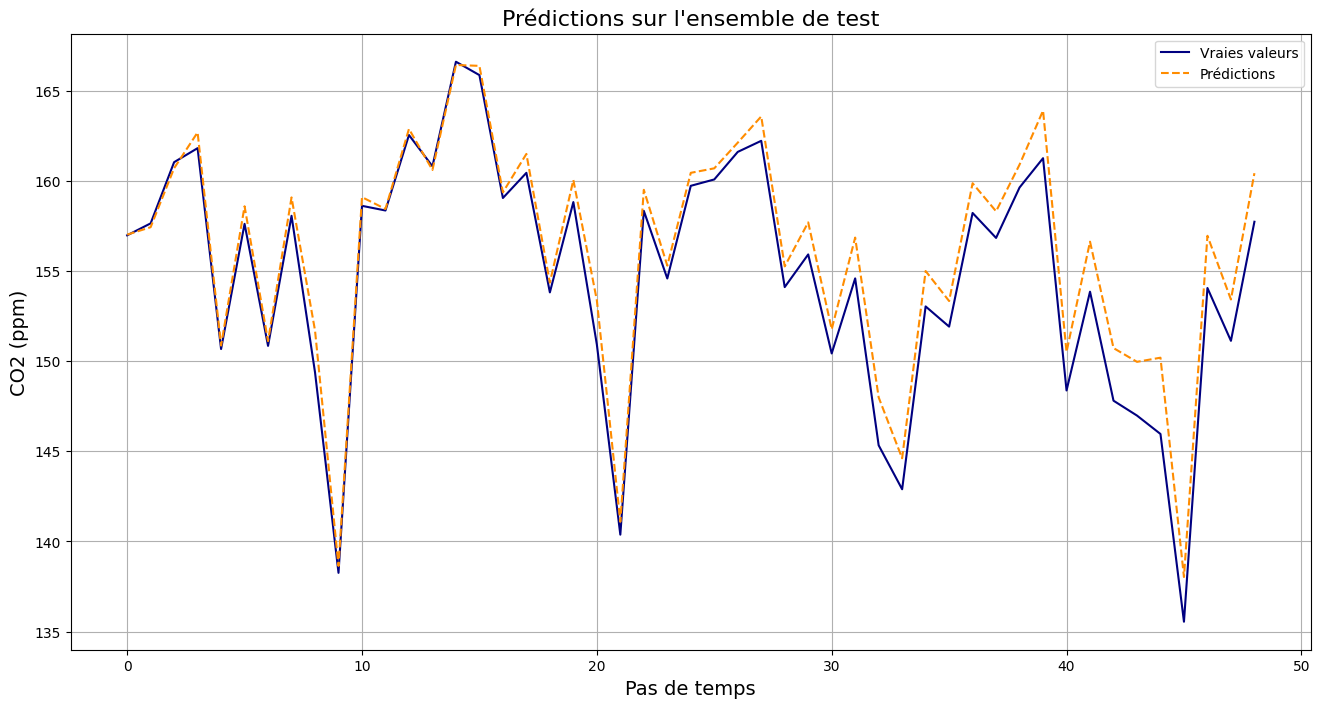

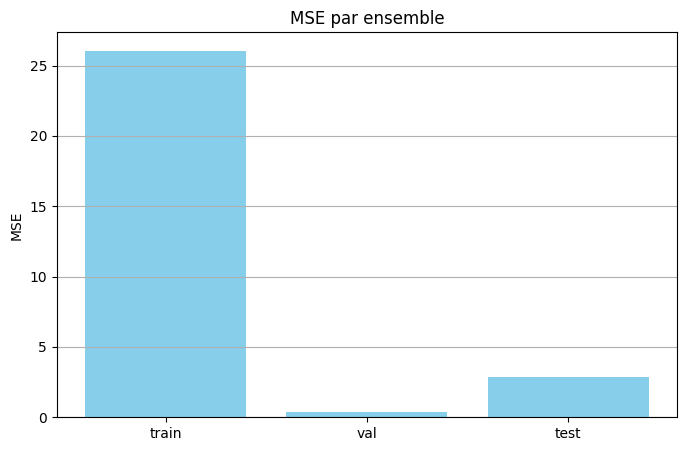

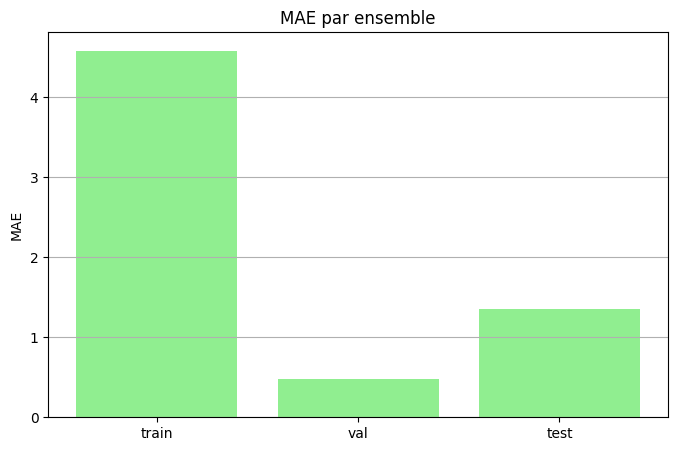

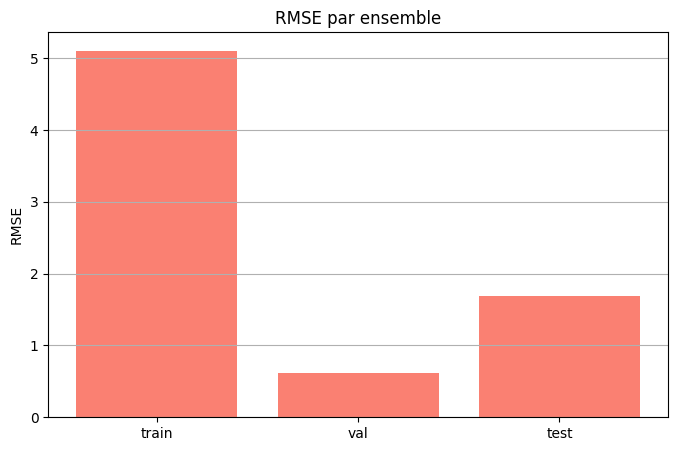

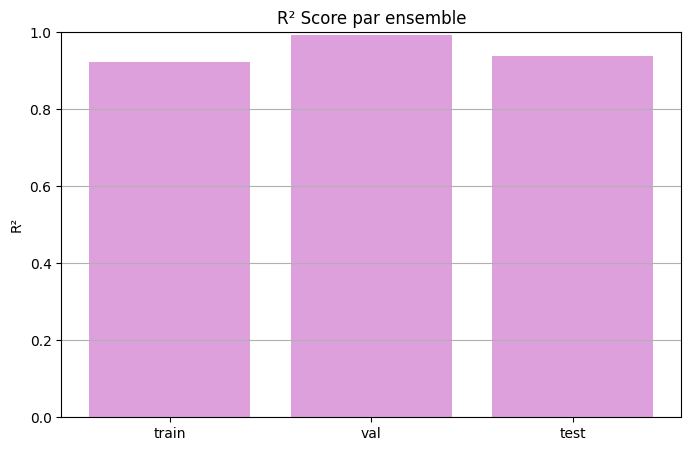

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import time

# Chargement des données
df = pd.read_csv('Emission.csv', parse_dates=['Year-Month'], index_col='Year-Month', dayfirst=False)
df.index = pd.to_datetime(df.index, format='%Y-%b')
df.columns = ['CO2']
df['month'] = df.index.month
df['sin_month'] = np.sin(2 * np.pi * df['month']/12)
df['cos_month'] = np.cos(2 * np.pi * df['month']/12)
df.drop('month', axis=1, inplace=True)
df['trend'] = np.arange(len(df))
df['CO2_diff'] = df['CO2'].diff().fillna(0)
df['CO2_diff_lag1'] = df['CO2_diff'].shift(1).fillna(0)


# Split
train = df.iloc[:int(0.7*len(df))]
val = df.iloc[int(0.7*len(df)):int(0.85*len(df))]
test = df.iloc[int(0.85*len(df)):]

# Normalisation
features = ['CO2_diff', 'sin_month', 'cos_month']
scaler = RobustScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train[features]), index=train.index, columns=features)
val_scaled = pd.DataFrame(scaler.transform(val[features]), index=val.index, columns=features)
test_scaled = pd.DataFrame(scaler.transform(test[features]), index=test.index, columns=features)

# Séquences
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data.iloc[i:i+n_steps].values)
        y.append(data.iloc[i+n_steps, 0])
    return np.array(X), np.array(y)

n_steps = 24
n_features = len(features)

X_train, y_train = create_sequences(train_scaled, n_steps)
X_val, y_val = create_sequences(val_scaled, n_steps)
X_test, y_test = create_sequences(test_scaled, n_steps)

# Bruit
noise = np.random.normal(0, 0.01, X_train.shape)
X_train_noisy = X_train + noise

class PositionalEncoding(tf.keras.layers.Layer):
    def call(self, inputs):
        positions = tf.range(start=0, limit=inputs.shape[1], delta=1)
        angles = tf.cast(positions[:, tf.newaxis], dtype=tf.float32) / tf.pow(10000., (2 * (tf.range(inputs.shape[-1]) // 2)) / tf.cast(inputs.shape[-1], tf.float32))
        pos_encoding = tf.where(tf.range(inputs.shape[-1]) % 2 == 0, tf.sin(angles), tf.cos(angles))
        return inputs + pos_encoding

# Bloc Transformer Encoder
def transformer_encoder(inputs, num_heads, ff_dim, dropout=0.1):
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=inputs.shape[-1])(inputs, inputs)
    attention_output = Dropout(dropout)(attention_output)
    out1 = LayerNormalization(epsilon=1e-6)(inputs + attention_output)

    ffn = Dense(ff_dim, activation="relu")(out1)
    ffn = Dense(inputs.shape[-1])(ffn)
    ffn = Dropout(dropout)(ffn)
    return LayerNormalization(epsilon=1e-6)(out1 + ffn)

# Modèle Transformer
input_layer = Input(shape=(n_steps, n_features))
x = transformer_encoder(input_layer, num_heads=2, ff_dim=64)
x = transformer_encoder(x, num_heads=2, ff_dim=64)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = Dropout(0.3)(x)
output = Dense(1)(x)

model = Model(inputs=input_layer, outputs=output)

# Compilation
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

# Entraînement
start_time = time.time()
history = model.fit(
    X_train_noisy, y_train,
    epochs=200,
    batch_size=24,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
training_time = time.time() - start_time

# Résumé
model.summary()

# Évaluation
def inverse_transform(y_diff, last_values):
    return last_values + y_diff.cumsum()

def evaluate_model(X, y, reference):
    start_time = time.time()
    y_pred = model.predict(X, verbose=0).flatten()
    pred_time = time.time() - start_time

    last_train_values = reference['CO2'].iloc[-len(y)-1:-1].values
    y_true = inverse_transform(y, last_train_values)
    y_pred = inverse_transform(y_pred, last_train_values)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
        'pred_time': pred_time,
        'true': y_true,
        'pred': y_pred
    }

results = {
    'train': evaluate_model(X_train, y_train, train),
    'val': evaluate_model(X_val, y_val, val),
    'test': evaluate_model(X_test, y_test, test)
}



  # === Résultats pour le Transformer ===
mse_train_transformer = results['train']['mse']
rmse_train_transformer = results['train']['rmse']
mae_train_transformer = results['train']['mae']
r2_train_transformer = results['train']['r2']

mse_val_transformer = results['val']['mse']
rmse_val_transformer = results['val']['rmse']
mae_val_transformer = results['val']['mae']
r2_val_transformer = results['val']['r2']

mse_test_transformer = results['test']['mse']
rmse_test_transformer = results['test']['rmse']
mae_test_transformer = results['test']['mae']
r2_test_transformer = results['test']['r2']

train_time_transformer = training_time
inference_time_transformer = results['test']['pred_time']
params_transformer = model.count_params()

# === Affichage des métriques ===
print(f"Temps d'entraînement total: {train_time_transformer:.2f} secondes\n")
print(f"=== Ensemble ENTRAÎNEMENT ===")
print(f"MSE: {mse_train_transformer:.4f}")
print(f"MAE: {mae_train_transformer:.4f}")
print(f"R²: {r2_train_transformer:.4f}")
print(f"Temps de prédiction: {inference_time_transformer:.4f} secondes\n")

print(f"=== Ensemble VALIDATION ===")
print(f"MSE: {mse_val_transformer:.4f}")
print(f"MAE: {mae_val_transformer:.4f}")
print(f"R²: {r2_val_transformer:.4f}")
print(f"Temps de prédiction: {inference_time_transformer:.4f} secondes\n")

print(f"=== Ensemble TEST ===")
print(f"MSE: {mse_test_transformer:.4f}")
print(f"MAE: {mae_test_transformer:.4f}")
print(f"R²: {r2_test_transformer:.4f}")
print(f"Temps de prédiction: {inference_time_transformer:.4f} secondes\n")


# === Visualisations ===
# Visualisation des prédictions vs valeurs réelles
plt.figure(figsize=(16, 8))
plt.plot(results['test']['true'], label='Vraies valeurs', color='navy')
plt.plot(results['test']['pred'], label='Prédictions', color='darkorange', linestyle='--')
plt.title('Prédictions sur l\'ensemble de test', fontsize=16)
plt.xlabel('Pas de temps', fontsize=14)
plt.ylabel('CO2 (ppm)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# VISUALISATION DES MÉTRIQUES
# Extraire les valeurs
datasets = ['train', 'val', 'test']
mse_values = [mse_train_transformer, mse_val_transformer, mse_test_transformer]
mae_values = [mae_train_transformer, mae_val_transformer, mae_test_transformer]
rmse_values = [rmse_train_transformer, rmse_val_transformer, rmse_test_transformer]
r2_values = [r2_train_transformer, r2_val_transformer, r2_test_transformer]

# Plot 1 : MSE
plt.figure(figsize=(8, 5))
plt.bar(datasets, mse_values, color='skyblue')
plt.title('MSE par ensemble')
plt.ylabel('MSE')
plt.grid(axis='y')
plt.show()

# Plot 2 : MAE
plt.figure(figsize=(8, 5))
plt.bar(datasets, mae_values, color='lightgreen')
plt.title('MAE par ensemble')
plt.ylabel('MAE')
plt.grid(axis='y')
plt.show()

# Plot 3 : RMSE
plt.figure(figsize=(8, 5))
plt.bar(datasets, rmse_values, color='salmon')
plt.title('RMSE par ensemble')
plt.ylabel('RMSE')
plt.grid(axis='y')
plt.show()

# Plot 4 : R²
plt.figure(figsize=(8, 5))
plt.bar(datasets, r2_values, color='plum')
plt.title('R² Score par ensemble')
plt.ylabel('R²')
plt.ylim(0, 1)  # car R² est généralement entre 0 et 1
plt.grid(axis='y')
plt.show()



Valeur prédite pour le prochain mois (25ᵉ mois): 152.92 ppm


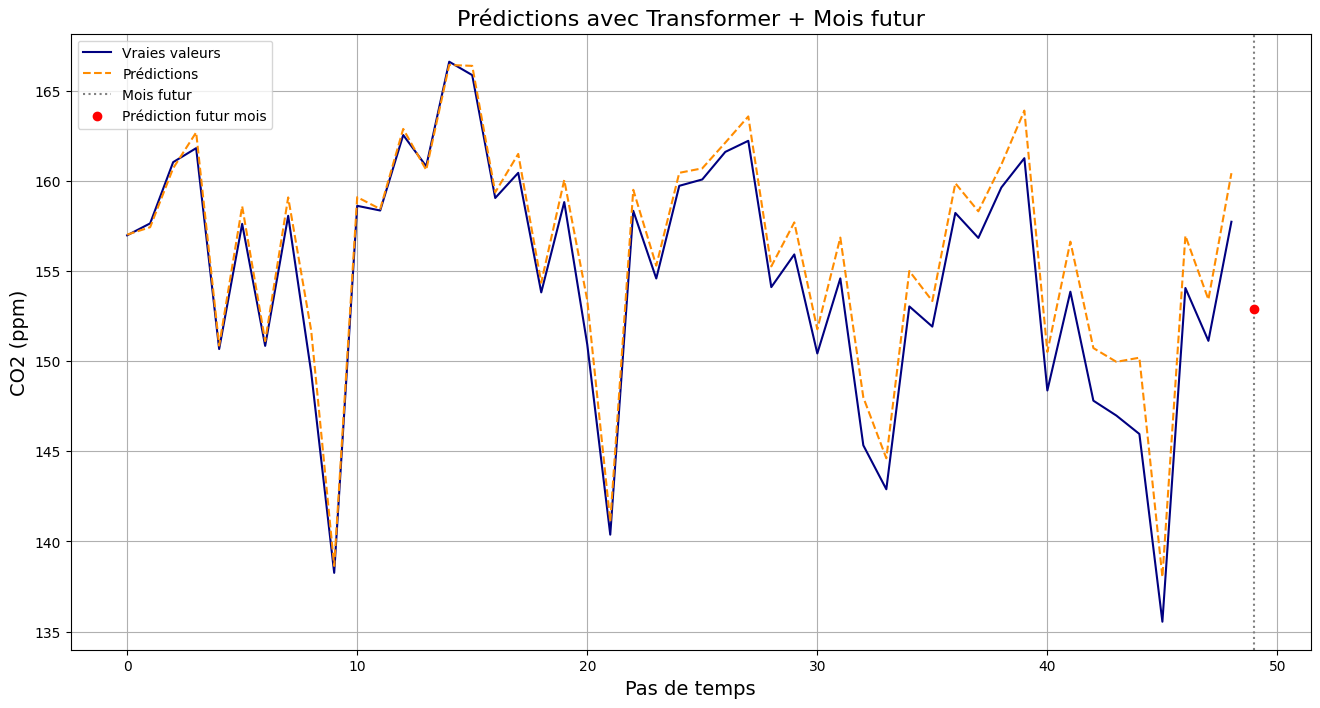

In [ ]:
# --- PRÉDICTION DU MOIS SUIVANT (25ᵉ mois)
# Préparer la dernière séquence connue (n_steps derniers points du test_scaled)
last_sequence = test_scaled.iloc[-n_steps:].values  # dernière fenêtre connue
last_sequence = last_sequence.reshape(1, n_steps, n_features)  # adapter la forme pour le modèle

# Prédire la différence future
future_diff = model.predict(last_sequence, verbose=0)[0][0]  # sortie : delta à ajouter

# Dernière valeur réelle connue
last_real_value = df['CO2'].iloc[-1]

# Calculer la vraie valeur prédite pour le 25ᵉ mois
future_value = last_real_value + future_diff

# Affichage du résultat
print(f"Valeur prédite pour le prochain mois (25ᵉ mois): {future_value:.2f} ppm")

# --- VISUALISATION ---

true_values = results['test']['true']
pred_values = results['test']['pred']

plt.figure(figsize=(16, 8))
plt.plot(true_values, label='Vraies valeurs', color='navy')
plt.plot(pred_values, label='Prédictions', color='darkorange', linestyle='--')

# Point pour le mois futur
plt.axvline(x=len(true_values), color='gray', linestyle=':', label='Mois futur')
plt.scatter(len(true_values), future_value, color='red', label='Prédiction futur mois', zorder=5)

plt.title("Prédictions avec Transformer + Mois futur", fontsize=16)
plt.xlabel("Pas de temps", fontsize=14)
plt.ylabel("CO2 (ppm)", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ---------------------------------comparaison--------------------
import pandas as pd

n_params_arima =3
# Crée un tableau de comparaison
results = {
    "Modèle": ["Arima", "Sarima", "Lstm","Transformer" ],
    "MSE (Test)": [ mse_test_arima, mse_test_sarima, mse_test_lstm , mse_test_transformer],
    "RMSE (Test)": [ mse_test_arima, rmse_test_sarima, rmse_test_lstm , rmse_test_transformer],
    "MAE (Test)": [ mse_test_arima, mae_test_sarima, mae_test_lstm, mae_test_transformer],
    "R² (Test)": [ mse_test_arima, r2_test_sarima, r2_test_lstm, r2_test_transformer],
    "Temps d'entraînement (s)": [ mse_test_arima, training_time_sarima, training_time_lstm , train_time_transformer],
    "Temps d'inférence (s)": [inference_test_time_arima, inference_time_sarima, inference_time_lstm , inference_time_transformer],
    "Nb Paramètres": [n_params_arima, n_params_sarima, n_params_lstm , params_transformer],
}

# Convertir en DataFrame
df_results = pd.DataFrame(results)

# Afficher le tableau
print(df_results)

        Modèle  MSE (Test)  RMSE (Test)  MAE (Test)  R² (Test)  \
0        Arima    0.040049     0.040049    0.040049   0.040049   
1       Sarima    0.011460     0.107050    0.092996   0.248728   
2         Lstm   12.488930     3.533968    2.632940   0.730039   
3  Transformer    2.840530     1.685387    1.358549   0.938599   

   Temps d'entraînement (s)  Temps d'inférence (s)  Nb Paramètres  
0                  0.040049               0.018129              3  
1                  0.391696               0.025948              4  
2                 61.575833               0.094822          30241  
3                 21.739296               0.121354           1116  


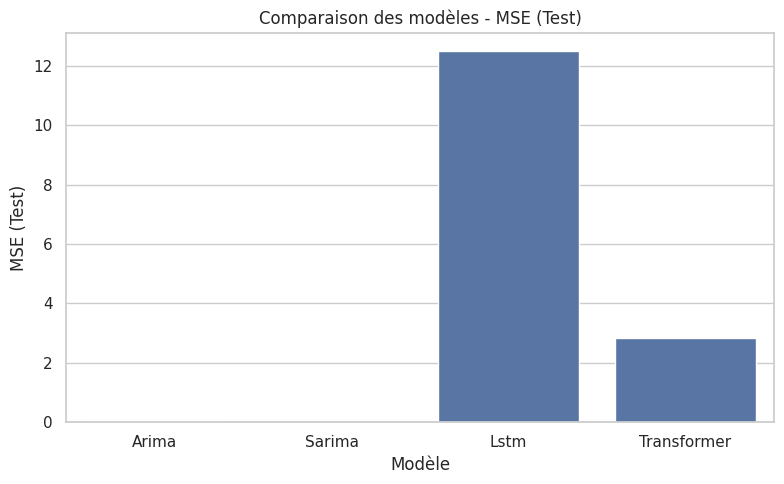

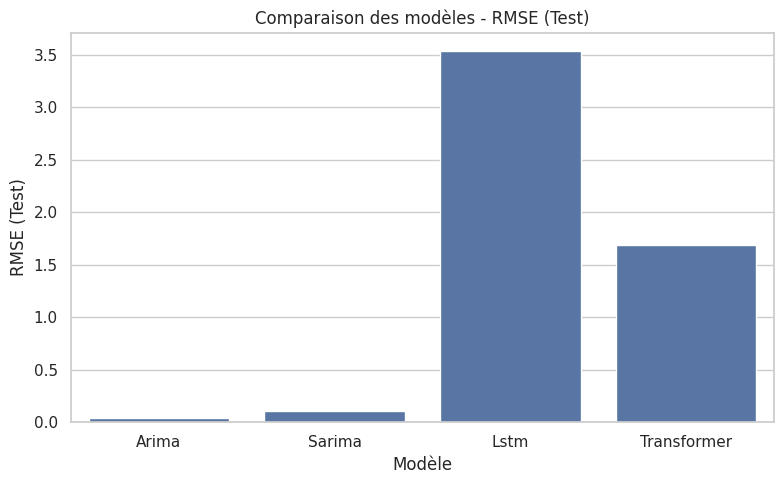

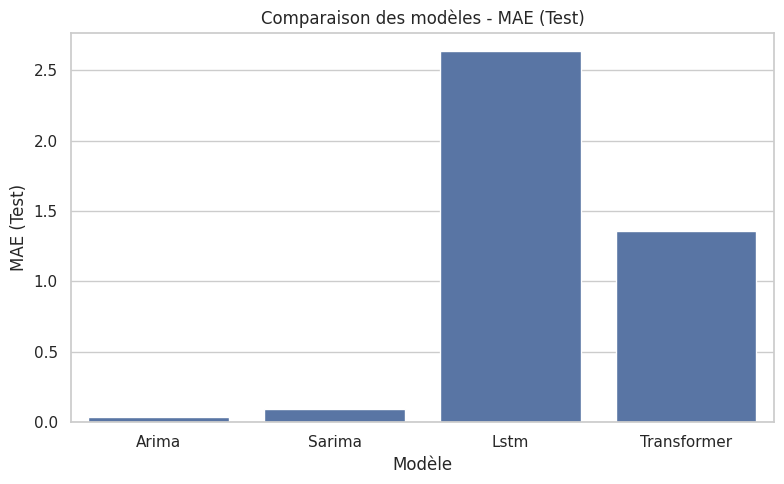

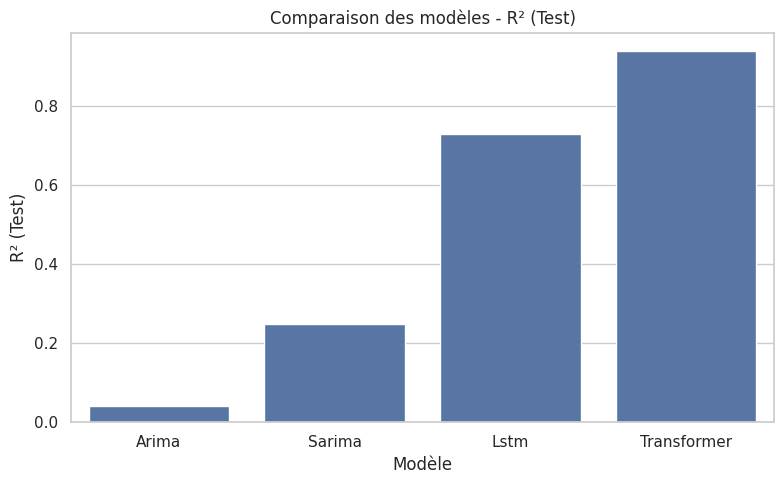

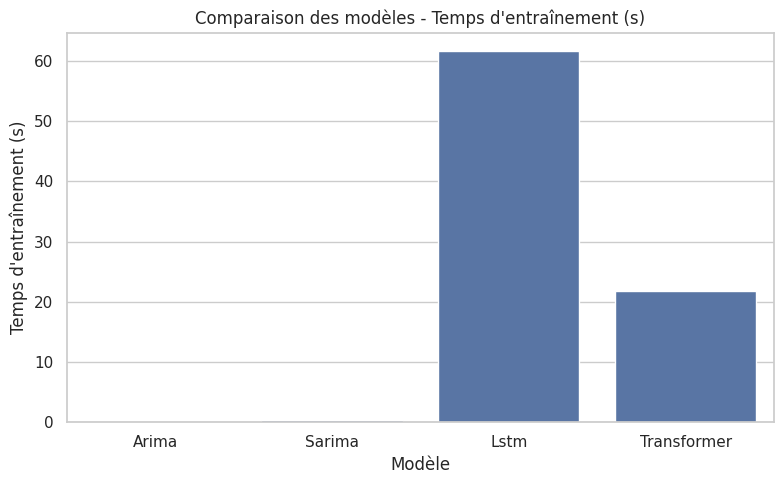

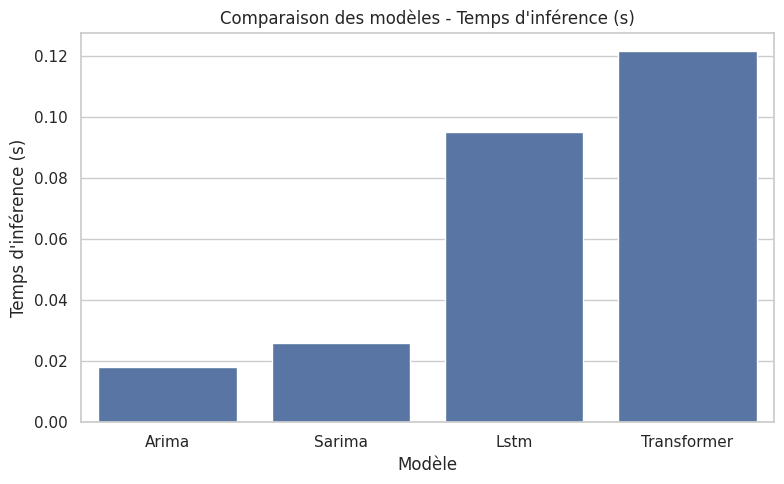

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Définir un style
sns.set(style="whitegrid")

# Convertir en DataFrame si ce n’est pas déjà fait
df_results = pd.DataFrame(results)

# Liste des métriques à tracer
metrics = ["MSE (Test)", "RMSE (Test)", "MAE (Test)", "R² (Test)", "Temps d'entraînement (s)", "Temps d'inférence (s)"]

# Création des barplots pour chaque métrique
for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.barplot(x="Modèle", y=metric, data=df_results)
    plt.title(f"Comparaison des modèles - {metric}")
    plt.ylabel(metric)
    plt.xlabel("Modèle")
    plt.tight_layout()
    plt.show()



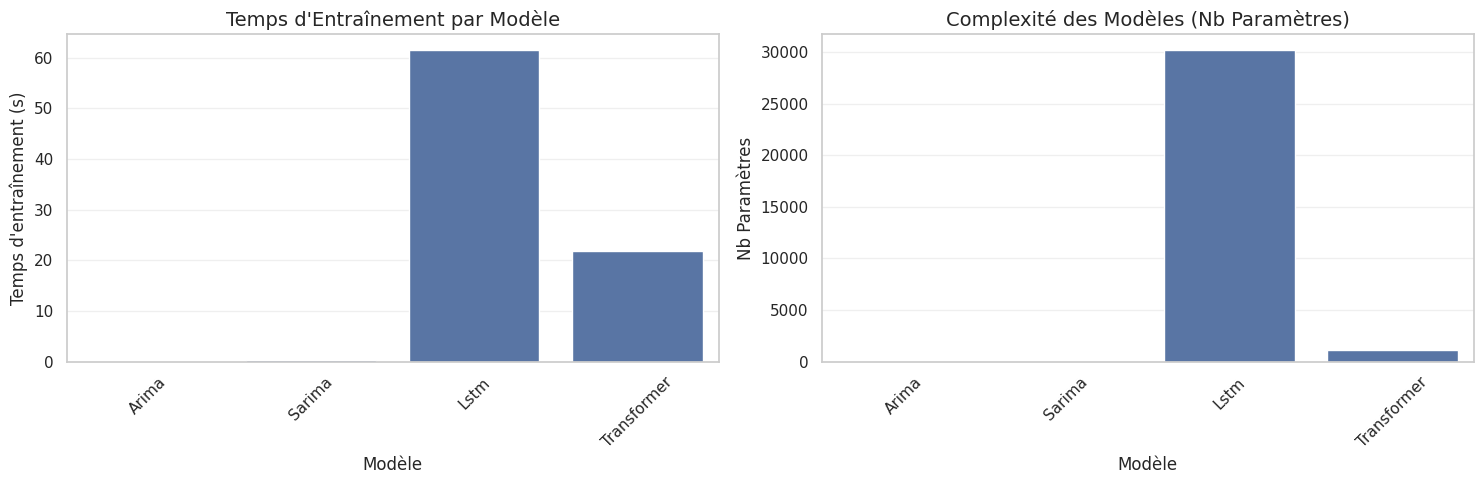

In [ ]:
plt.figure(figsize=(15, 5))

# Temps d'entraînement
plt.subplot(1, 2, 1)
sns.barplot(x='Modèle', y='Temps d\'entraînement (s)', data=df_results)
plt.title('Temps d\'Entraînement par Modèle', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)

# Nombre de paramètres
plt.subplot(1, 2, 2)
sns.barplot(x='Modèle', y='Nb Paramètres', data=df_results)
plt.title('Complexité des Modèles (Nb Paramètres)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

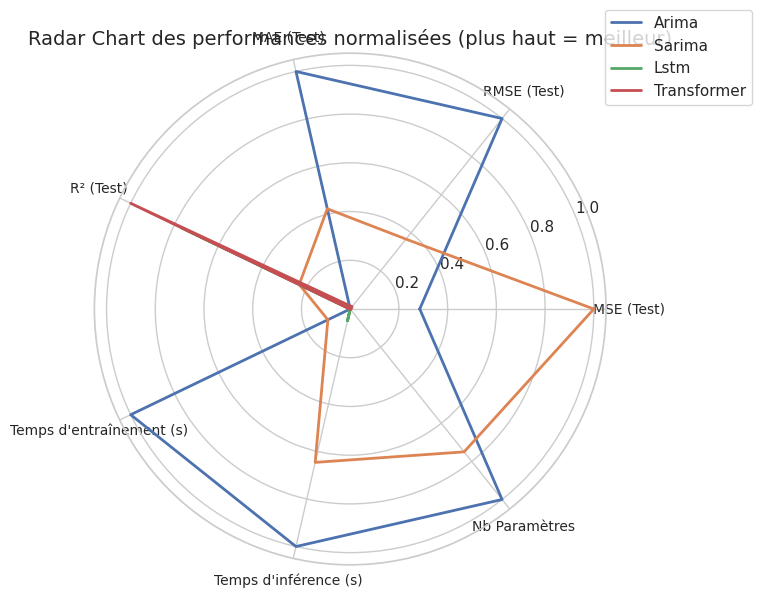

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# On crée un nouveau DataFrame pour les métriques à comparer
metrics_cols = [
    "MSE (Test)", "RMSE (Test)", "MAE (Test)", "R² (Test)",
    "Temps d'entraînement (s)", "Temps d'inférence (s)",
    "Nb Paramètres"
]
df_metrics = df.set_index("Modèle")[metrics_cols]

# Inverser les métriques où "plus petit = meilleur"
cols_to_inverse = ["MSE (Test)", "RMSE (Test)", "MAE (Test)", "Temps d'entraînement (s)", "Temps d'inférence (s)", "Nb Paramètres"]
df_metrics[cols_to_inverse] = 1 / (df_metrics[cols_to_inverse] + 1e-6)  # éviter division par zéro

# Normalisation
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_metrics),
    index=df_metrics.index,
    columns=df_metrics.columns
)

# Radar chart
labels = df_scaled.columns.tolist()
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # pour fermer le polygone

plt.figure(figsize=(8, 8))
for model in df_scaled.index:
    values = df_scaled.loc[model].tolist()
    values += values[:1]
    plt.polar(angles, values, label=model, linewidth=2)

plt.xticks(angles[:-1], labels, fontsize=10)
plt.title("Radar Chart des performances normalisées (plus haut = meilleur)", size=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()